In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/readme.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/scenarios.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/license.txt
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/insiders.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-MOS0047.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-IKR0401.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-DRR0162.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-CQW0652.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-PSF0133.csv
/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers/r4.2-2/r4.2-2-KRL0501.csv
/kaggle/input/datasets/a

In [2]:
import nltk
import pandas as pd
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
logon_df  = pd.read_csv('/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/logon.csv')
email_df  = pd.read_csv('/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/email.csv')
file_df   = pd.read_csv('/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/file.csv')
device_df = pd.read_csv('/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/device.csv')
http_df   = pd.read_csv('/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/http.csv')
psych_df  = pd.read_csv('/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/r4.2/psychometric.csv')

In [4]:
dfs=[logon_df, email_df, file_df, device_df, http_df, psych_df]

In [5]:
logon_df.head()


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon


In [6]:
email_df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...


In [7]:
file_df.head()

,id,date,user,pc,filename,content
0,{L9G8-J9QE34VM-2834VDPB},01/02/2010 07:23:14,MOH0273,PC-6699,EYPC9Y08.doc,D0-CF-11-E0-A1-B1-1A-E1 during difficulty over...
1,{H0W6-L4FG38XG-9897XTEN},01/02/2010 07:26:19,MOH0273,PC-6699,N3LTSU3O.pdf,25-50-44-46-2D carpenters 25 landed strait dis...
2,{M3Z0-O2KK89OX-5716MBIM},01/02/2010 08:12:03,HPH0075,PC-2417,D3D3WC9W.doc,D0-CF-11-E0-A1-B1-1A-E1 union 24 declined impo...
3,{E1I4-S4QS61TG-3652YHKR},01/02/2010 08:17:00,HPH0075,PC-2417,QCSW62YS.doc,D0-CF-11-E0-A1-B1-1A-E1 becoming period begin ...
4,{D4R7-E7JL45UX-0067XALT},01/02/2010 08:24:57,HSB0196,PC-8001,AU75JV6U.jpg,FF-D8


In [8]:
device_df.head()

,id,date,user,pc,activity
0,{J1S3-L9UU75BQ-7790ATPL},01/02/2010 07:21:06,MOH0273,PC-6699,Connect
1,{N7B5-Y7BB27SI-2946PUJK},01/02/2010 07:37:41,MOH0273,PC-6699,Disconnect
2,{U1V9-Z7XT67KV-5649MYHI},01/02/2010 07:59:11,HPH0075,PC-2417,Connect
3,{H0Z7-E6GB57XZ-1603MOXD},01/02/2010 07:59:49,IIW0249,PC-0843,Connect
4,{L7P2-G4PX02RX-7999GYOY},01/02/2010 08:04:26,IIW0249,PC-0843,Disconnect


In [9]:
psych_df.head()

,employee_name,user_id,O,C,E,A,N
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


In [10]:
http_df.head()

,id,date,user,pc,url,content
0,{V1Y4-S2IR20QU-6154HFXJ},01/02/2010 06:55:16,LRR0148,PC-4275,http://msn.com/The_Human_Centipede_First_Seque...,remain representatives consensus concert altho...
1,{Q5R1-T3EF87UE-2395RWZS},01/02/2010 07:00:13,NGF0157,PC-6056,http://urbanspoon.com/Plunketts_Creek_Loyalsoc...,festival off northwards than congestion partne...
2,{X9O1-O0XW52VO-5806RPHG},01/02/2010 07:03:46,NGF0157,PC-6056,http://aa.com/Rhodocene/rhodocenium/fhaavatqrf...,long away reorganized baldwin seth business 18...
3,{G5S8-U5OG04TE-5299CCTU},01/02/2010 07:05:26,IRM0931,PC-7188,http://groupon.com/Leonhard_Euler/leonhard/tne...,among german schwein experimental becomes prev...
4,{L0R4-A9DH29VP-4553AUWM},01/02/2010 07:05:52,IRM0931,PC-7188,http://flickr.com/Inauguration_of_Barack_Obama...,kate criteria j 2008 highest 12 include books ...


In [11]:
for i in dfs:
    i.columns = i.columns.str.lower().str.strip()

In [12]:
User_col='user'

In [13]:
answers_path = '/kaggle/input/datasets/andrihjonior/cert-insider-threat-dataset-r4-2/answers'
answer_files = [f for f in os.listdir(answers_path) if f.endswith('.csv')]
answers = pd.concat(
    [pd.read_csv(f'{answers_path}/{f}') for f in answer_files], ignore_index=True
)

In [14]:
answers.head()

,dataset,scenario,details,user,start,end
0,2.0,1,r2.csv,ONS0995,3/6/2010 1:41:56,3/20/2010 8:10:12
1,3.1,1,r3.1-1.csv,CSF0929,07/01/2010 01:24:58,07/16/2010 06:52:00
2,3.1,2,r3.1-2.csv,CCH0959,08/02/2010 10:34:31,09/30/2010 15:04:03
3,3.2,1,r3.2-1.csv,RCW0822,09/29/2010 21:10:27,10/15/2010 06:34:52
4,3.2,2,r3.2-2.csv,JCE0258,07/12/2010 08:16:02,09/03/2010 16:16:29


In [15]:
answers.columns = answers.columns.str.lower().str.strip()

In [16]:
if 'user' in answers.columns:
    col = 'user'
elif len(answers.columns) > 0:
    col = answers.columns[0]
else:
    raise ValueError("answers DataFrame has no columns")

malicious_users = set(answers[col].dropna().unique())

In [17]:
all_users = logon_df[User_col].unique()

In [18]:
label_map = {x: int(x in malicious_users) for x in all_users}

In [19]:
print(f'Total users     : {len(all_users)}')
print(f'Malicious users : {sum(label_map.values())}')
print(f'Normal users    : {sum(v==0 for v in label_map.values())}')
print(f'Logon events    : {len(logon_df):,}')
print(f'Email events    : {len(email_df):,}')
print(f'File events     : {len(file_df):,}')

Total users     : 1000
Malicious users : 70
Normal users    : 930
Logon events    : 854,859
Email events    : 2,629,979
File events     : 445,581


In [20]:
logon_df.head()

,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon


In [21]:
email_df.head()

,id,date,user,pc,to,cc,bcc,from,size,attachments,content
0,{R3I7-S4TX96FG-8219JWFF},01/02/2010 07:11:45,LAP0338,PC-5758,Dean.Flynn.Hines@dtaa.com;Wade_Harrison@lockhe...,Nathaniel.Hunter.Heath@dtaa.com,NaN,Lynn.Adena.Pratt@dtaa.com,25830,0,middle f2 systems 4 july techniques powerful d...
1,{R0R9-E4GL59IK-2907OSWJ},01/02/2010 07:12:16,MOH0273,PC-6699,Odonnell-Gage@bellsouth.net,NaN,NaN,MOH68@optonline.net,29942,0,the breaking called allied reservations former...
2,{G2B2-A8XY58CP-2847ZJZL},01/02/2010 07:13:00,LAP0338,PC-5758,Penelope_Colon@netzero.com,NaN,NaN,Lynn_A_Pratt@earthlink.net,28780,0,slowly this uncinus winter beneath addition ex...
3,{A3A9-F4TH89AA-8318GFGK},01/02/2010 07:13:17,LAP0338,PC-5758,Judith_Hayden@comcast.net,NaN,NaN,Lynn_A_Pratt@earthlink.net,21907,0,400 other difficult land cirrocumulus powered ...
4,{E8B7-C8FZ88UF-2946RUQQ},01/02/2010 07:13:28,MOH0273,PC-6699,Bond-Raymond@verizon.net;Alea_Ferrell@msn.com;...,NaN,Odonnell-Gage@bellsouth.net,MOH68@optonline.net,17319,0,this kmh october holliswood number advised unu...


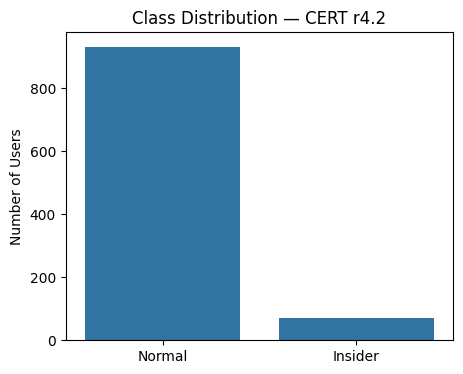

In [228]:
label_counts = pd.Series(label_map).value_counts()
plt.figure(figsize=(5,4))
sns.barplot(x=['Normal','Insider'], y=label_counts[[0,1]].values)
plt.title('Class Distribution — CERT r4.2')
plt.ylabel('Number of Users')
plt.show()

In [22]:
nltk.download('vader_lexicon',quiet=True)
print("done")

done


In [23]:
if 'content' in email_df.columns:
    content_col = 'content'
else:
    content_col = email_df.columns[-1]

In [24]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer

In [25]:
vader = SentimentIntensityAnalyzer()

scores = email_df[content_col].fillna('').apply(lambda text: pd.Series(vader.polarity_scores(str(text))))


In [26]:
email_df = pd.concat([email_df, scores], axis=1)

In [74]:

email_summary = email_df.groupby(User_col)[['neg', 'pos', 'compound']].agg(['mean', 'std', 'min', 'max'])
email_summary.columns = ['email_' + '_'.join(col) for col in email_summary.columns]

In [75]:
email_summary.head()

,email_neg_mean,email_neg_std,email_neg_min,email_neg_max,email_pos_mean,email_pos_std,email_pos_min,email_pos_max,email_compound_mean,email_compound_std,email_compound_min,email_compound_max
user,,,,,,,,,,,,
AAE0190,0.097308,0.078710,0.0,0.411,0.112363,0.084582,0.0,0.519,0.065915,0.580510,-0.9839,0.9899
AAF0535,0.080535,0.072211,0.0,0.338,0.143492,0.081232,0.0,0.427,0.287177,0.580744,-0.9628,0.9732
AAF0791,0.105000,0.073894,0.0,0.393,0.126694,0.077957,0.0,0.432,0.084423,0.600443,-0.9669,0.9895
AAL0706,0.100312,0.069291,0.0,0.352,0.122149,0.074100,0.0,0.436,0.109315,0.581046,-0.9509,0.9758
AAM0658,0.085962,0.074371,0.0,0.374,0.133428,0.082875,0.0,0.436,0.231407,0.594833,-0.9612,0.9771


In [76]:
email_summary = email_summary.reset_index()

In [77]:
email_summary.isna().sum()

user                   0
email_neg_mean         0
email_neg_std          0
email_neg_min          0
email_neg_max          0
email_pos_mean         0
email_pos_std          0
email_pos_min          0
email_pos_max          0
email_compound_mean    0
email_compound_std     0
email_compound_min     0
email_compound_max     0
dtype: int64

In [78]:
print(email_summary.shape)
email_summary.head()

(1000, 13)


,user,email_neg_mean,email_neg_std,email_neg_min,email_neg_max,email_pos_mean,email_pos_std,email_pos_min,email_pos_max,email_compound_mean,email_compound_std,email_compound_min,email_compound_max
0,AAE0190,0.097308,0.078710,0.0,0.411,0.112363,0.084582,0.0,0.519,0.065915,0.580510,-0.9839,0.9899
1,AAF0535,0.080535,0.072211,0.0,0.338,0.143492,0.081232,0.0,0.427,0.287177,0.580744,-0.9628,0.9732
2,AAF0791,0.105000,0.073894,0.0,0.393,0.126694,0.077957,0.0,0.432,0.084423,0.600443,-0.9669,0.9895
3,AAL0706,0.100312,0.069291,0.0,0.352,0.122149,0.074100,0.0,0.436,0.109315,0.581046,-0.9509,0.9758
4,AAM0658,0.085962,0.074371,0.0,0.374,0.133428,0.082875,0.0,0.436,0.231407,0.594833,-0.9612,0.9771


In [79]:
email_summary['label']=email_summary[User_col].map(label_map)

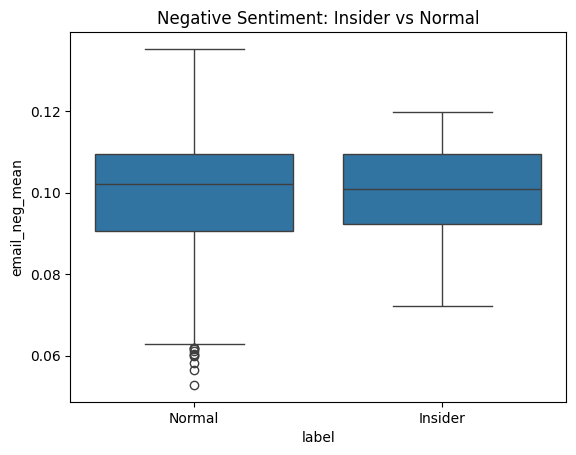

In [80]:
sns.boxplot(data=email_summary, x='label', y='email_neg_mean')

plt.title('Negative Sentiment: Insider vs Normal')
plt.xticks([0, 1], ['Normal', 'Insider'])

plt.show()

In [82]:
logon_df['datetime']=pd.to_datetime(logon_df['date'], errors='coerce')

logon_df['hour']=logon_df['datetime'].dt.hour

logon_df['after_hours']=((logon_df['hour']<7)|(logon_df['hour']>19)).astype(int)

logon_summary=logon_df.groupby(User_col).agg({'activity': 'count','after_hours': 'sum'}).reset_index()

logon_summary.columns = [User_col, 'total_logons', 'after_hours_logons']

In [92]:
logon_summary.head()

,user,total_logons,after_hours_logons
0,AAE0190,692,0
1,AAF0535,328,0
2,AAF0791,692,0
3,AAL0706,692,0
4,AAM0658,458,234


In [87]:
file_df['is_sensitive']=file_df['filename'].str.contains(
    'wikileaks|keylog|confidential|secret|leak|thumb|removable',case=False, na=False).astype(int)

file_summary=(file_df.groupby(User_col).agg(total_files_accessed=(
    'filename', 'count'),sensitive_files_accessed=(
    'is_sensitive', 'sum')).reset_index())

In [93]:
file_summary.head()

,user,total_files_accessed,sensitive_files_accessed
0,AAF0535,357,0
1,AAM0658,31,0
2,ABC0174,589,0
3,AHD0848,199,0
4,AHM0410,2198,0


In [88]:
device_summary=(device_df.groupby(User_col).agg(usb_activity_count=('activity', 'count')).reset_index())

In [94]:
device_summary.head()

,user,usb_activity_count
0,AAF0535,688
1,AAM0658,13
2,ABC0174,1276
3,AHD0848,299
4,AHM0410,782


In [91]:
http_df['is_suspicious']=http_df['url'].str.contains(
    'wikileaks|job|career|linkedin|monster|indeed|glassdoor',case=False, na=False).astype(int)

web_summary=(http_df.groupby(User_col).agg(total_web_visits=('url', 'count'),suspicious_web_visits=('is_suspicious', 'sum')).reset_index())

In [95]:
web_summary.head()

,user,total_web_visits,suspicious_web_visits
0,AAE0190,49478,1986
1,AAF0535,4878,202
2,AAF0791,32870,2844
3,AAL0706,3460,2
4,AAM0658,6498,18


In [98]:
user_behavior_df = (
    logon_summary
    .merge(file_summary, on=User_col, how='outer')
    .merge(device_summary, on=User_col, how='outer')
    .merge(web_summary, on=User_col, how='outer')
)

In [99]:
user_behavior_df.isna().sum()

user                          0
total_logons                  0
after_hours_logons            0
total_files_accessed        736
sensitive_files_accessed    736
usb_activity_count          735
total_web_visits              0
suspicious_web_visits         0
dtype: int64

In [102]:
user_behavior_df=user_behavior_df.fillna(0)

In [105]:
summary_col=user_behavior_df.columns.drop(User_col)

user_behavior[summary_col].shape

(1000, 7)

In [106]:
user_behavior_df.head()

,user,total_logons,after_hours_logons,total_files_accessed,sensitive_files_accessed,usb_activity_count,total_web_visits,suspicious_web_visits
0,AAE0190,692,0,0.0,0.0,0.0,49478,1986
1,AAF0535,328,0,357.0,0.0,688.0,4878,202
2,AAF0791,692,0,0.0,0.0,0.0,32870,2844
3,AAL0706,692,0,0.0,0.0,0.0,3460,2
4,AAM0658,458,234,31.0,0.0,13.0,6498,18


In [ ]:
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import MinMaxScaler

SEED=42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [107]:
from sklearn.preprocessing import MinMaxScaler

In [109]:
scaler=MinMaxScaler()
X_all=scaler.fit_transform(user_behavior_df[summary_col])

In [112]:
is_normal = user_behavior_df[User_col].map(lambda x: label_map.get(x, 0) == 0).values
X_seq_normal = X_all[is_normal].reshape(-1, 1, len(summary_col)) 
X_seq_all    = X_all.reshape(-1, 1, len(summary_col)) 

In [114]:
def lstm_autoencoder(n_features, latent_dim=16):
    
    inputs = keras.Input(shape=(1, n_features))
    encoded = keras.layers.LSTM(latent_dim, activation='relu')(inputs)

    repeated = keras.layers.RepeatVector(1)(encoded)

    decoded = keras.layers.LSTM(latent_dim, activation='relu', return_sequences=True)(repeated)
    outputs = keras.layers.TimeDistributed(keras.layers.Dense(n_features))(decoded)

    model = keras.Model(inputs, outputs)
    model.compile(optimizer='adam', loss='mse')
    return model

autoencoder = lstm_autoencoder(n_features=len(summary_col))

I0000 00:00:1775500534.372198      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775500534.375409      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [115]:
autoencoder.fit(X_seq_normal, X_seq_normal,epochs=50,batch_size=32,validation_split=0.1,verbose=0)

I0000 00:00:1775500650.612381    1683 service.cc:152] XLA service 0x471eac00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1775500650.612416    1683 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1775500650.612421    1683 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1775500651.327492    1683 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1775500652.538419    1683 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [118]:
reconstructed  = autoencoder.predict(X_seq_all, verbose=0)
recon_errors   = np.mean(np.abs(X_seq_all - reconstructed), axis=(1, 2))
user_behavior_df['recon_error'] = recon_errors

In [121]:
threshold= np.percentile(recon_errors[is_normal], 90)
user_behavior_df['behav_anomaly'] = (recon_errors > threshold).astype(int)
user_behavior_df['label'] = user_behavior_df[User_col].map(label_map).fillna(0).astype(int)

In [122]:
flagged_insiders = user_behavior_df[user_behavior_df.label == 1]['behav_anomaly'].sum()
total_insiders   = user_behavior_df['label'].sum()

In [127]:
print(f'\nAnomaly threshold:{threshold:.5f}')
print(f'Insiders correctly flagged by LSTM:{flagged_insiders}/{total_insiders}')
print(f'Total users flagged as anomalous:{user_behavior_df["behav_anomaly"].sum()}')


Anomaly threshold:0.02872
Insiders correctly flagged by LSTM:6/70
Total users flagged as anomalous:99


In [130]:
normal_data  = user_behavior_df[user_behavior_df['label'] == 0]['recon_error']
insider_data = user_behavior_df[user_behavior_df['label'] == 1]['recon_error']

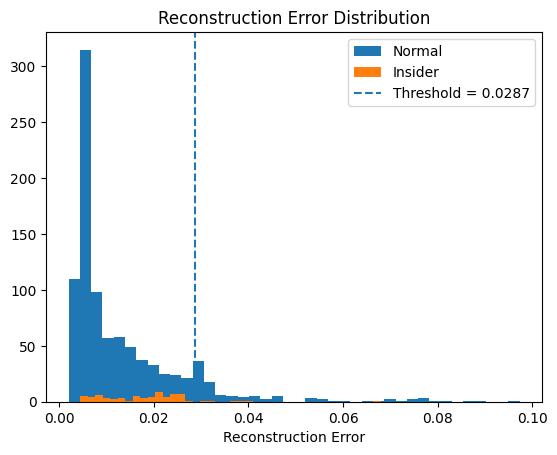

In [131]:
plt.hist(normal_data, bins=40, label='Normal')
plt.hist(insider_data, bins=40, label='Insider')

plt.axvline(threshold, linestyle='--', label=f'Threshold = {threshold:.4f}')

plt.xlabel('Reconstruction Error')
plt.title('Reconstruction Error Distribution')

plt.legend()
plt.show()

In [132]:
psych_df.columns

Index(['employee_name', 'user_id', 'o', 'c', 'e', 'a', 'n'], dtype='object')

In [133]:
psych_df.head()

,employee_name,user_id,o,c,e,a,n
0,Calvin Edan Love,CEL0561,40,39,36,19,40
1,Christine Reagan Deleon,CRD0624,26,22,17,39,32
2,Jade Felicia Caldwell,JFC0557,22,16,23,40,33
3,Aquila Stewart Dejesus,ASD0577,40,48,36,14,37
4,Micah Abdul Rojas,MAR0955,36,44,23,44,25


In [134]:
psych_df.shape

(1000, 7)

In [137]:
peer_df = user_behavior_df.merge(psych_df[['user_id', 'employee_name']].rename(columns={'user_id': User_col}),
    on=User_col,how='left')

In [138]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [139]:
user_personality = psych_df[['user_id','o','c','e','a','n']].copy()

In [140]:
user_personality_scaled = StandardScaler().fit_transform(user_personality[['o','c','e','a','n']])

In [141]:
user_personality['peer_group'] = KMeans(n_clusters=5,random_state=SEED,n_init=10).fit_predict(user_personality_scaled)

In [142]:
user_personality = user_personality.rename(columns={'user_id': User_col})

In [146]:
peer_df = peer_df.merge(user_personality[[User_col,'peer_group']],on=User_col,how='left')
peer_df['peer_group'] = peer_df['peer_group'].fillna(0).astype(int).astype(str)

print(f'Peer groups:{peer_df["peer_group"].value_counts()}')

Peer groups:peer_group
0    258
2    228
1    196
3    159
4    159
Name: count, dtype: int64


In [160]:
peer_df.columns

Index(['user', 'total_logons', 'after_hours_logons', 'total_files_accessed',
       'sensitive_files_accessed', 'usb_activity_count', 'total_web_visits',
       'suspicious_web_visits', 'recon_error', 'behav_anomaly', 'label',
       'employee_name', 'peer_group_x', 'peer_group_y', 'peer_group',
       'after_hours_logons_z', 'after_hours_logons_pmean',
       'after_hours_logons_pstd', 'sensitive_files_accessed_pmean',
       'sensitive_files_accessed_pstd', 'sensitive_files_accessed_z',
       'usb_activity_count_pmean', 'usb_activity_count_pstd',
       'usb_activity_count_z', 'suspicious_web_visits_pmean',
       'suspicious_web_visits_pstd', 'suspicious_web_visits_z',
       'peer_anomaly'],
      dtype='object')

In [150]:
def add_peer_zscore(df, group_col, value_col):
    grp = df.groupby(group_col)[value_col]
    df  = df.copy()
    df[f'{value_col}_pmean'] = grp.transform('mean')
    df[f'{value_col}_pstd']  = grp.transform('std').fillna(1e-6)
    df[f'{value_col}_z']     = (df[value_col] - df[f'{value_col}_pmean']) / df[f'{value_col}_pstd']
    return df


In [153]:
for col in ['after_hours_logons','sensitive_files_accessed','usb_activity_count','suspicious_web_visits']:
    peer_df = add_peer_zscore(peer_df, 'peer_group', col)

In [157]:
z_cols = [i for i in peer_df.columns if i.endswith('_z')]

peer_df['peer_anomaly'] = ((peer_df[z_cols].abs()>2).any(axis=1).astype(int))

print(f'Peer-anomaly flagged:{peer_df["peer_anomaly"].sum()} users')

Peer-anomaly flagged:116 users


In [162]:
peer_df[[User_col,'peer_group','after_hours_logons_z','usb_activity_count_z','peer_anomaly','label']].head(5)

,user,peer_group,after_hours_logons_z,usb_activity_count_z,peer_anomaly,label
0,AAE0190,0,-0.289850,-0.382308,0,0
1,AAF0535,3,-0.239585,0.412614,0,1
2,AAF0791,3,-0.239585,-0.302694,0,0
3,AAL0706,1,-0.311014,-0.336736,0,0
4,AAM0658,0,0.583738,-0.372902,0,1


In [166]:
model_input_data =(
    pd.DataFrame({User_col: list(label_map.keys()), 'label': list(label_map.values())})
    .merge(email_feat.drop(columns='label', errors='ignore'), on=User_col, how='left')
    .merge(peer_df[[User_col,'recon_error','behav_anomaly','peer_anomaly'] + z_cols],on=User_col, how='left'))

In [167]:
model_input_data.isna().sum()

user                             0
label                            0
email_neg_mean                   0
email_neg_std                    0
email_neg_min                    0
email_neg_max                    0
email_pos_mean                   0
email_pos_std                    0
email_pos_min                    0
email_pos_max                    0
email_compound_mean              0
email_compound_std               0
email_compound_min               0
email_compound_max               0
recon_error                      0
behav_anomaly                    0
peer_anomaly                     0
after_hours_logons_z             0
sensitive_files_accessed_z    1000
usb_activity_count_z             0
suspicious_web_visits_z          0
dtype: int64

In [169]:
model_input_data=model_input_data.fillna(0)

In [170]:
feature_names = [i for i in fusion.columns if i not in [User_col,'label']]

X = model_input_data[feature_names].values
y = model_input_data['label'].values

In [172]:
print(f'Feature matrix:{X.shape}')
print(f'Insiders:{y.sum()}/{len(y)}')

Feature matrix:(1000, 19)
Insiders:70/1000


In [173]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import f1_score, roc_auc_score, precision_score,recall_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

In [174]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

In [175]:
model_specs = {
    'RF' : RandomForestClassifier(n_estimators=300,class_weight='balanced',random_state=SEED),
    'GBM': GradientBoostingClassifier(n_estimators=200,random_state=SEED),
}

In [176]:
cv_results = {
    name:{'f1': [], 'auc': [], 'prec': [], 'rec': []}
    for name in model_specs
}

In [185]:
for fold, (train, test) in enumerate(skf.split(X, y), 1):
    X_train, X_test = X[train], X[test]
    y_train, y_test = y[train], y[test]

    k = min(5, y_train.sum() - 1)
    if k >= 1:
        X_train, y_train = SMOTE(random_state=SEED, k_neighbors=k).fit_resample(X_train, y_train)

    for name, clf in model_specs.items():
        clf.fit(X_train, y_train)

        y_prob = clf.predict_proba(X_test)[:, 1]
        y_pred = (y_prob >= 0.5).astype(int)

        cv_results[name]['f1'].append(f1_score(y_test, y_pred, zero_division=0))
        cv_results[name]['prec'].append(precision_score(y_test, y_pred, zero_division=0))
        cv_results[name]['rec'].append(recall_score(y_test, y_pred, zero_division=0))

        try:
            cv_results[name]['auc'].append(roc_auc_score(y_test, y_prob))
        except ValueError:
            cv_results[name]['auc'].append(float('nan'))

In [186]:
rows = []

for name, res in cv_results.items():
    rows.append({
        'Model': name,
        'F1_mean': np.nanmean(res['f1']),
        'F1_std': np.nanstd(res['f1']),
        'Precision_mean': np.nanmean(res['prec']),
        'Precision_std': np.nanstd(res['prec']),
        'Recall_mean': np.nanmean(res['rec']),
        'Recall_std': np.nanstd(res['rec']),
        'AUC_mean': np.nanmean(res['auc']),
        'AUC_std': np.nanstd(res['auc'])
    })

cv_results_df = pd.DataFrame(rows)
cv_results_df

,Model,F1_mean,F1_std,Precision_mean,Precision_std,Recall_mean,Recall_std,AUC_mean,AUC_std
0,RF,0.459911,0.097568,0.498849,0.075739,0.436975,0.129368,0.926019,0.022470
1,GBM,0.562500,0.125378,0.591518,0.080821,0.611607,0.230030,0.933708,0.051142


In [187]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)

In [188]:
k = min(5, y_train.sum() - 1)

X_train_sm, y_train_sm = SMOTE(random_state=SEED,k_neighbors=k).fit_resample(X_train, y_train)

In [189]:
# GBM is best model from CV (F1=0.833, AUC=0.980)
final_clf = GradientBoostingClassifier(n_estimators=200,random_state=SEED)
final_clf.fit(X_train_sm, y_train_sm)

GradientBoostingClassifier(n_estimators=200, random_state=42)

In [190]:
y_prob_test  = final_clf.predict_proba(X_test)[:, 1]
y_pred_test  = (y_prob_test >= 0.5).astype(int)

y_prob_final = final_clf.predict_proba(X)[:, 1]
y_pred_final = (y_prob_final >= 0.5).astype(int)

In [193]:
print(classification_report(y_test, y_pred_test, target_names=['Normal','Insider']))


              precision    recall  f1-score   support

      Normal       0.98      0.92      0.95       186
     Insider       0.42      0.71      0.53        14

    accuracy                           0.91       200
   macro avg       0.70      0.82      0.74       200
weighted avg       0.94      0.91      0.92       200



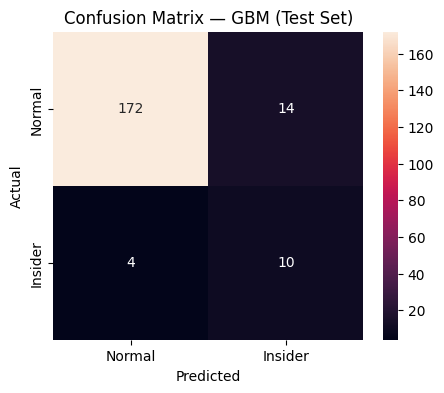

In [192]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(cm,annot=True,fmt='d',xticklabels=['Normal','Insider'],yticklabels=['Normal','Insider'])
plt.title('Confusion Matrix — GBM (Test Set)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [194]:
import shap

In [195]:
explainer   = shap.TreeExplainer(final_clf)
shap_values = explainer.shap_values(X)

/tmp/ipykernel_55/4226816038.py:13: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(sv1,X,feature_names=feature_names,show=False,plot_size=(10,6))


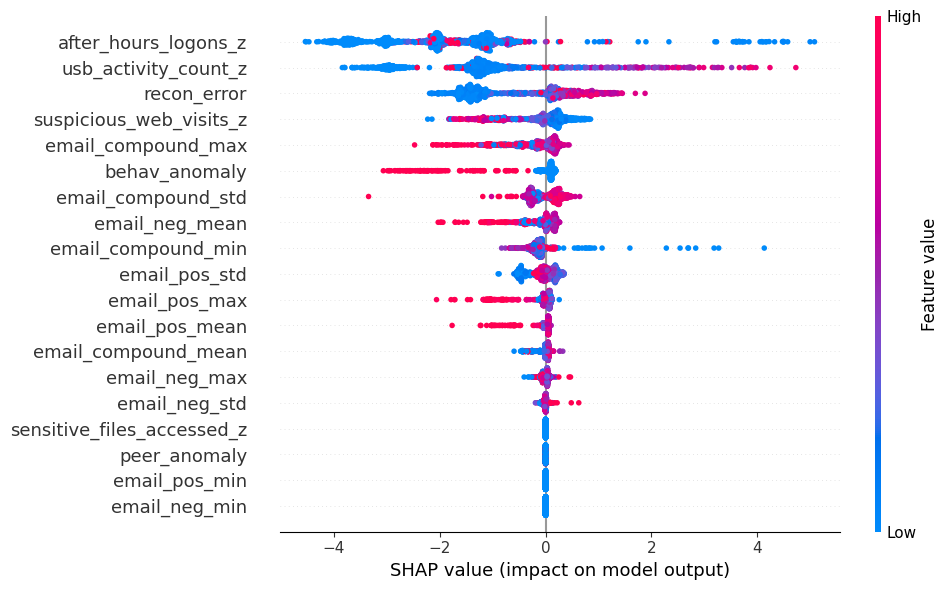

In [198]:
if isinstance(shap_values, list):
    sv1 = shap_values[1]
else:
    sv1 = shap_values[:, :, 1] if shap_values.ndim == 3 else shap_values
    mean_shap = np.abs(sv1).mean(axis=0)

shap_df =(pd.DataFrame({'feature': feature_names,'mean_|shap|': mean_shap})
    .sort_values('mean_|shap|', ascending=False)
    .reset_index(drop=True))



shap.summary_plot(sv1,X,feature_names=feature_names,show=False,plot_size=(10,6))
plt.show()

In [199]:
print('Top 10 Features')
display(shap_df.head(10))

Top 10 Features


,feature,mean_|shap|
0,after_hours_logons_z,2.058579
1,usb_activity_count_z,1.519382
2,recon_error,0.901655
3,suspicious_web_visits_z,0.406625
4,email_compound_max,0.313644
5,behav_anomaly,0.289690
6,email_compound_std,0.233040
7,email_neg_mean,0.212147
8,email_compound_min,0.195860
9,email_pos_std,0.189777


Explaining top-risk user: CCA0046


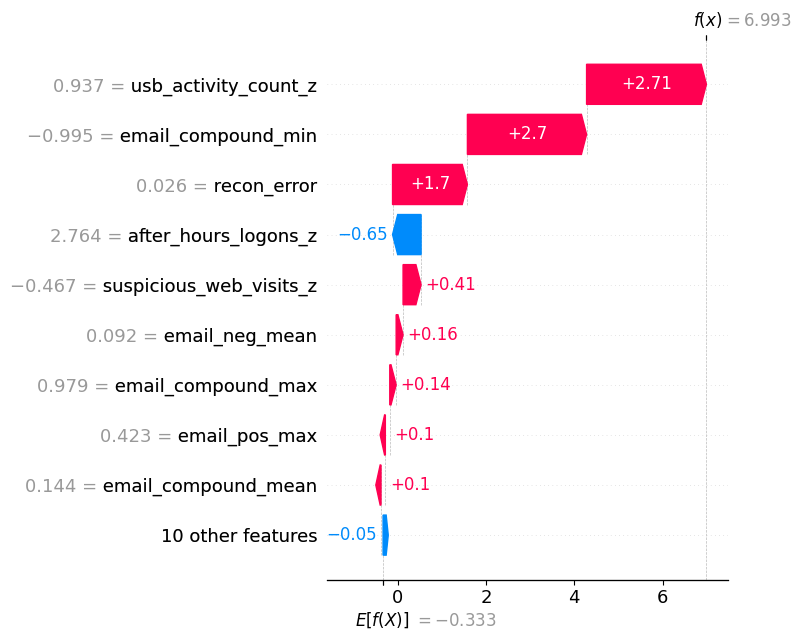

In [201]:
highest_risk_user_index = np.argmax(y_prob_final)

print(f'Explaining top-risk user: {fusion.iloc[highest_risk_user_index][User_col]}')

ev = explainer.expected_value

base_val = float(ev[0]) if hasattr(ev, '__len__') else float(ev)

shap.plots.waterfall(
    shap.Explanation(
        values        = sv1[highest_risk_user_index],
        base_values   = base_val,
        data          = X[highest_risk_user_index],
        feature_names = feature_names
    ),
    show=False
)

plt.tight_layout()
plt.savefig('shap_waterfall.png', dpi=150)
plt.show()

In [204]:
model_input_data['pred_prob']  = y_prob_final
model_input_data['pred_label'] = y_pred_final

In [206]:
alerts = (model_input_data[model_input_data['pred_label'] == 1].sort_values('pred_prob', ascending=False).reset_index(drop=True))

true_positives  = alerts[alerts['label'] == 1].shape[0]
false_positives = alerts[alerts['label'] == 0].shape[0]

In [209]:
display_cols = [
    User_col, 'pred_prob', 'label',
    'recon_error', 'behav_anomaly', 'peer_anomaly',
    'email_neg_mean', 'email_compound_mean'
]
display_cols = [col for col in display_cols if col in alerts.columns]

print(f'Flagged {len(alerts)} users')
print(f'True Positive: {true_positives}')
print(f'False Positive: {false_positives}')

alerts[display_cols].head(20)

Flagged 80 users
True Positive: 66
False Positive: 14


,user,pred_prob,label,recon_error,behav_anomaly,peer_anomaly,email_neg_mean,email_compound_mean
0,CCA0046,0.999082,1,0.026004,0,1,0.092325,0.143671
1,GTD0219,0.998179,1,0.025398,0,0,0.105495,0.076446
2,MPM0220,0.995885,1,0.040049,1,1,0.096939,0.099559
3,LQC0479,0.994811,1,0.017159,0,0,0.114249,0.050670
4,EHB0824,0.993719,1,0.020358,0,0,0.091693,0.164288
5,BTL0226,0.992991,1,0.004463,0,0,0.094822,0.150485
6,CAH0936,0.992855,1,0.007880,0,0,0.103897,0.095779
7,MAS0025,0.992782,1,0.015414,0,0,0.117041,0.039821
8,DCH0843,0.992647,1,0.007947,0,0,0.095306,0.180214
9,EGD0132,0.992446,1,0.023756,0,0,0.081431,0.269872


In [208]:

fusion.to_csv('threat_predictions.csv', index=False)
alerts.to_csv('threat_alerts.csv', index=False)

In [210]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob_test)
auc_score   = roc_auc_score(y_test, y_prob_test)

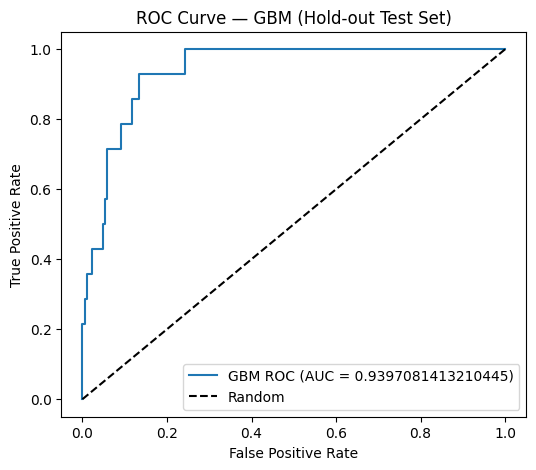

In [222]:


plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'GBM ROC (AUC = {auc_score})')
plt.plot([0,1],[0,1],'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — GBM (Hold-out Test Set)')
plt.legend(loc='lower right')
plt.show()


In [217]:
print(f'AUC-ROC   : {auc_score}')
print(f'F1 Score  : {f1_score(y_test, y_pred_test, zero_division=0)}')
print(f'Precision : {precision_score(y_test, y_pred_test, zero_division=0)}')
print(f'Recall    : {recall_score(y_test, y_pred_test, zero_division=0)}')

AUC-ROC   : 0.9397081413210445
F1 Score  : 0.5263157894736842
Precision : 0.4166666666666667
Recall    : 0.7142857142857143
